# 03 - Sales Forecasting Model

Predict daily `Revenue` and `COGS` for `2023-01-01` to `2024-07-01`.

This notebook is organized as a single reproducible training workflow:

1. Data preparation
2. Feature engineering
3. Validation design
4. Model training
5. Forecast generation
6. Explainability
7. Reproducibility artifacts

## 1. Data Preparation

The released analytical `sales.csv` is already processed as a daily table. This section only:

- Parses `Date`
- Sorts chronologically
- Keeps the daily sales table in the expected modeling shape


In [1]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "analytical"
MODEL_DIR = PROJECT_ROOT / "models"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"
REPORT_DIR = PROJECT_ROOT / "reports" / "tables"

SALES_PATH = DATA_DIR / "sales.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"
SUBMISSION_PATH = SUBMISSION_DIR / "submission_03_2_ensemble_forecast.csv"
VALIDATION_RESULTS_PATH = REPORT_DIR / "03_2_ensemble_validation_results.csv"
ENSEMBLE_WEIGHTS_PATH = REPORT_DIR / "03_2_ensemble_weights.csv"
MODEL_CONFIG_PATH = MODEL_DIR / "03_2_ensemble_model_config.json"
FEATURE_IMPORTANCE_PATH = REPORT_DIR / "03_2_ensemble_feature_importance.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["Revenue", "COGS"]
LAGS = [1, 7, 14, 30, 365]
ROLLING_WINDOWS = [7, 30, 90, 365]
FORECAST_START = pd.Timestamp("2023-01-01")
FORECAST_END = pd.Timestamp("2024-07-01")
VALIDATION_YEAR = 2022

In [2]:
sales_raw = pd.read_csv(SALES_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

sales_raw["Date"] = pd.to_datetime(sales_raw["Date"])
sample_submission["Date"] = pd.to_datetime(sample_submission["Date"])

sales_raw = sales_raw.sort_values("Date").reset_index(drop=True)
sample_submission = sample_submission.sort_values("Date").reset_index(drop=True)

print("Sales shape:", sales_raw.shape)
print("Sales date range:", sales_raw["Date"].min().date(), "to", sales_raw["Date"].max().date())
print("Sample submission shape:", sample_submission.shape)
print("Submission date range:", sample_submission["Date"].min().date(), "to", sample_submission["Date"].max().date())
sales_raw.head()

Sales shape: (3833, 3)
Sales date range: 2012-07-04 to 2022-12-31
Sample submission shape: (548, 3)
Submission date range: 2023-01-01 to 2024-07-01


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [3]:
# The analytical sales file is already a processed daily table, so no missing-date filling or imputation is applied.
daily_sales = sales_raw[["Date", *TARGET_COLS]].copy()

assert daily_sales["Date"].is_monotonic_increasing
assert daily_sales[TARGET_COLS].notna().all().all()
assert not daily_sales["Date"].duplicated().any()

print("Daily sales table:", daily_sales.shape)
daily_sales.tail()


Daily sales table: (3833, 3)


,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


## 2. Feature Engineering

Features are designed to avoid target leakage:

- Calendar features are known in advance.
- Cyclical features encode day/week/month/annual seasonality.
- Lag features use only previous observed or previously predicted values.
- Rolling features are shifted by one day, so the current target value is never used to predict itself.
- Optional internal exogenous features are based on shifted historical target relationships only.

In [4]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = out["Date"].dt
    iso = dt.isocalendar()

    out["year"] = dt.year
    out["quarter"] = dt.quarter
    out["month"] = dt.month
    out["weekofyear"] = iso.week.astype(int)
    out["dayofyear"] = dt.dayofyear
    out["dayofmonth"] = dt.day
    out["dayofweek"] = dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["is_month_start"] = dt.is_month_start.astype(int)
    out["is_month_end"] = dt.is_month_end.astype(int)
    out["is_quarter_start"] = dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = dt.is_quarter_end.astype(int)
    out["is_year_start"] = dt.is_year_start.astype(int)
    out["is_year_end"] = dt.is_year_end.astype(int)
    return out


def add_cyclical_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    cycles = {
        "dayofweek": 7,
        "dayofyear": 366,
        "month": 12,
        "weekofyear": 53,
    }
    for col, period in cycles.items():
        angle = 2 * np.pi * out[col] / period
        out[f"{col}_sin"] = np.sin(angle)
        out[f"{col}_cos"] = np.cos(angle)
    return out


def add_lag_rolling_features(df: pd.DataFrame, target_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for target in target_cols:
        shifted = out[target].shift(1)
        for lag in LAGS:
            out[f"{target}_lag_{lag}"] = out[target].shift(lag)
        for window in ROLLING_WINDOWS:
            out[f"{target}_roll_mean_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).mean()
            out[f"{target}_roll_std_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).std()
            out[f"{target}_roll_min_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).min()
            out[f"{target}_roll_max_{window}"] = shifted.rolling(window, min_periods=max(2, window // 3)).max()

    # Leakage-safe internal exogenous features: all are shifted or historical expanding values.
    out["gross_margin_lag_1"] = (out["Revenue"].shift(1) - out["COGS"].shift(1))
    out["cogs_to_revenue_lag_1"] = out["COGS"].shift(1) / out["Revenue"].shift(1).replace(0, np.nan)
    out["revenue_expanding_mean"] = out["Revenue"].shift(1).expanding(min_periods=30).mean()
    out["cogs_expanding_mean"] = out["COGS"].shift(1).expanding(min_periods=30).mean()
    return out


def make_features(df: pd.DataFrame, target_cols: list[str] = TARGET_COLS) -> pd.DataFrame:
    out = add_calendar_features(df)
    out = add_cyclical_features(out)
    out = add_lag_rolling_features(out, target_cols)
    return out

feature_table = make_features(daily_sales)
feature_cols = [c for c in feature_table.columns if c not in ["Date", *TARGET_COLS]]
model_table = feature_table.dropna(subset=feature_cols + TARGET_COLS).reset_index(drop=True)

print("Feature table shape:", feature_table.shape)
print("Model-ready table shape:", model_table.shape)
print("Feature count:", len(feature_cols))
model_table[["Date", *TARGET_COLS] + feature_cols[:8]].head()

Feature table shape: (3833, 71)
Model-ready table shape: (3468, 71)
Feature count: 68


,Date,Revenue,COGS,year,quarter,month,weekofyear,dayofyear,dayofmonth,dayofweek,is_weekend
0,2013-07-04,2521315.44,2408274.98,2013,3,7,27,185,4,3,0
1,2013-07-05,2494107.65,2432073.97,2013,3,7,27,186,5,4,0
2,2013-07-06,2452372.43,2331799.51,2013,3,7,27,187,6,5,1
3,2013-07-07,2958215.01,2950992.63,2013,3,7,27,188,7,6,1
4,2013-07-08,2571901.18,2450996.77,2013,3,7,28,189,8,0,0


## 3. Validation Design

Validation approach:

- Time-series cross-validation is used for directional model comparison.
- Main validation trains through `2021-12-31` and validates on calendar year `2022`.
- Metrics: MAE, RMSE, and R² for both targets.

In [5]:
def regression_metrics(y_true: pd.DataFrame | np.ndarray, y_pred: np.ndarray, model_name: str) -> pd.DataFrame:
    true = pd.DataFrame(y_true, columns=TARGET_COLS)
    pred = pd.DataFrame(y_pred, columns=TARGET_COLS)
    rows = []
    for target in TARGET_COLS:
        rmse = math.sqrt(mean_squared_error(true[target], pred[target]))
        rows.append({
            "model": model_name,
            "target": target,
            "MAE": mean_absolute_error(true[target], pred[target]),
            "RMSE": rmse,
            "R2": r2_score(true[target], pred[target]),
        })
    rows.append({
        "model": model_name,
        "target": "average",
        "MAE": float(np.mean([r["MAE"] for r in rows])),
        "RMSE": float(np.mean([r["RMSE"] for r in rows])),
        "R2": float(np.mean([r["R2"] for r in rows])),
    })
    return pd.DataFrame(rows)

train_mask = model_table["Date"] < pd.Timestamp(f"{VALIDATION_YEAR}-01-01")
val_mask = (model_table["Date"] >= pd.Timestamp(f"{VALIDATION_YEAR}-01-01")) & (model_table["Date"] <= pd.Timestamp(f"{VALIDATION_YEAR}-12-31"))

X_train = model_table.loc[train_mask, feature_cols]
y_train = model_table.loc[train_mask, TARGET_COLS]
X_val = model_table.loc[val_mask, feature_cols]
y_val = model_table.loc[val_mask, TARGET_COLS]

print("Main train range:", model_table.loc[train_mask, "Date"].min().date(), "to", model_table.loc[train_mask, "Date"].max().date())
print("Main validation range:", model_table.loc[val_mask, "Date"].min().date(), "to", model_table.loc[val_mask, "Date"].max().date())
print("Train rows:", len(X_train), "Validation rows:", len(X_val))

Main train range: 2013-07-04 to 2021-12-31
Main validation range: 2022-01-01 to 2022-12-31
Train rows: 3103 Validation rows: 365


In [6]:
ts_cv = TimeSeriesSplit(n_splits=5, test_size=365)
cv_summary = []
for fold, (train_idx, test_idx) in enumerate(ts_cv.split(model_table), start=1):
    fold_train_dates = model_table.iloc[train_idx]["Date"]
    fold_test_dates = model_table.iloc[test_idx]["Date"]
    cv_summary.append({
        "fold": fold,
        "train_start": fold_train_dates.min().date(),
        "train_end": fold_train_dates.max().date(),
        "valid_start": fold_test_dates.min().date(),
        "valid_end": fold_test_dates.max().date(),
        "train_rows": len(train_idx),
        "valid_rows": len(test_idx),
    })

pd.DataFrame(cv_summary)

,fold,train_start,train_end,valid_start,valid_end,train_rows,valid_rows
0,1,2013-07-04,2018-01-01,2018-01-02,2019-01-01,1643,365
1,2,2013-07-04,2019-01-01,2019-01-02,2020-01-01,2008,365
2,3,2013-07-04,2020-01-01,2020-01-02,2020-12-31,2373,365
3,4,2013-07-04,2020-12-31,2021-01-01,2021-12-31,2738,365
4,5,2013-07-04,2021-12-31,2022-01-01,2022-12-31,3103,365


## 4. Model Training

Models:

- Seasonal naive baseline: same date last year (`t - 365`).
- Ridge regression.
- Random Forest.
- Final model: LightGBM if available, otherwise XGBoost.
- Hyperparameters are selected by the 2022 validation score.

In [13]:
validation_results = []
validation_predictions = {}
models = {}

# Seasonal naive baseline uses engineered lag_365 features.
# seasonal_naive_pred = X_val[["Revenue_lag_365", "COGS_lag_365"]].to_numpy()
# validation_predictions["seasonal_naive"] = seasonal_naive_pred
# validation_results.append(regression_metrics(y_val, seasonal_naive_pred, "seasonal_naive"))

ridge_model = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=10.0, random_state=RANDOM_SEED)),
)
ridge_model.fit(X_train, y_train)
models["ridge"] = ridge_model
ridge_pred = ridge_model.predict(X_val)
validation_predictions["ridge"] = ridge_pred
validation_results.append(regression_metrics(y_val, ridge_pred, "ridge"))

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
models["random_forest"] = rf_model
rf_pred = rf_model.predict(X_val)
validation_predictions["random_forest"] = rf_pred
validation_results.append(regression_metrics(y_val, rf_pred, "random_forest"))

validation_table = pd.concat(validation_results, ignore_index=True)
validation_table


,model,target,MAE,RMSE,R2
0,ridge,Revenue,634901.142550,875867.622632,0.726180
1,ridge,COGS,557289.245312,757127.291003,0.730546
2,ridge,average,596095.193931,816497.456818,0.728363
3,random_forest,Revenue,583477.705756,818333.492596,0.760972
4,random_forest,COGS,507091.134023,712169.502145,0.761596
5,random_forest,average,545284.419890,765251.497371,0.761284


In [14]:
def get_boosting_estimator(params: dict):
    try:
        from lightgbm import LGBMRegressor
        estimator = LGBMRegressor(
            objective="regression",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbosity=-1,
            **params,
        )
        return "lightgbm", estimator
    except Exception:
        from xgboost import XGBRegressor
        estimator = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method="hist",
            **params,
        )
        return "xgboost", estimator

candidate_params = [
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 4, "num_leaves": 31, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 800, "learning_rate": 0.02, "max_depth": 5, "num_leaves": 45, "subsample": 0.9, "colsample_bytree": 0.8},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 3, "num_leaves": 15, "subsample": 0.8, "colsample_bytree": 0.9},
]

boosting_trials = []
best_boosting = None
best_score = np.inf

for trial_id, params in enumerate(candidate_params, start=1):
    library, base_estimator = get_boosting_estimator(params)
    model = MultiOutputRegressor(base_estimator)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    model_name = f"{library}_trial_{trial_id}"
    models[model_name] = model
    validation_predictions[model_name] = pred
    metrics = regression_metrics(y_val, pred, model_name)
    avg_rmse = float(metrics.loc[metrics["target"] == "average", "RMSE"].iloc[0])
    boosting_trials.append({"trial": trial_id, "model_name": model_name, "library": library, "avg_RMSE": avg_rmse, **params})
    validation_results.append(metrics)
    if avg_rmse < best_score:
        best_score = avg_rmse
        best_boosting = {"library": library, "model": model, "params": params, "trial": trial_id, "model_name": model_name}

validation_table = pd.concat(validation_results, ignore_index=True)
boosting_trials_df = pd.DataFrame(boosting_trials).sort_values("avg_RMSE")

print("Best individual boosting model:", best_boosting["library"], "trial", best_boosting["trial"])
boosting_trials_df


Best individual boosting model: lightgbm trial 2


,trial,model_name,library,avg_RMSE,n_estimators,learning_rate,max_depth,num_leaves,subsample,colsample_bytree
1,2,lightgbm_trial_2,lightgbm,721490.270639,800,0.02,5,45,0.9,0.8
2,3,lightgbm_trial_3,lightgbm,723125.946095,500,0.05,3,15,0.8,0.9
0,1,lightgbm_trial_1,lightgbm,725316.474880,500,0.03,4,31,0.9,0.9


In [15]:
validation_table.sort_values(["target", "RMSE"]).reset_index(drop=True)

,model,target,MAE,RMSE,R2
0,lightgbm_trial_2,COGS,480174.369023,665173.640203,0.792022
1,lightgbm_trial_1,COGS,479207.104411,666327.325197,0.791300
2,lightgbm_trial_3,COGS,476175.600048,666907.394947,0.790937
3,random_forest,COGS,507091.134023,712169.502145,0.761596
4,ridge,COGS,557289.245312,757127.291003,0.730546
5,lightgbm_trial_2,Revenue,562680.908611,777806.901075,0.784061
6,lightgbm_trial_3,Revenue,556147.603779,779344.497244,0.783206
7,lightgbm_trial_1,Revenue,572399.179724,784305.624564,0.780437
8,random_forest,Revenue,583477.705756,818333.492596,0.760972
9,ridge,Revenue,634901.142550,875867.622632,0.726180


In [16]:
def optimize_ensemble_weights(y_true: pd.DataFrame, prediction_dict: dict[str, np.ndarray]) -> tuple[dict[str, np.ndarray], pd.DataFrame, np.ndarray, list[str]]:
    model_names = list(prediction_dict.keys())
    weights_by_target = {}
    rows = []
    ensemble_pred = np.zeros((len(y_true), len(TARGET_COLS)))

    for target_idx, target in enumerate(TARGET_COLS):
        y = y_true[target].to_numpy(dtype=float)
        pred_matrix = np.column_stack([prediction_dict[name][:, target_idx] for name in model_names])

        def objective(weights: np.ndarray) -> float:
            return math.sqrt(mean_squared_error(y, pred_matrix @ weights))

        start = np.repeat(1 / len(model_names), len(model_names))
        result = minimize(
            objective,
            start,
            method="SLSQP",
            bounds=[(0.0, 1.0)] * len(model_names),
            constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
            options={"maxiter": 500, "ftol": 1e-10},
        )
        weights = np.maximum(result.x, 0)
        weights = weights / weights.sum()
        weights_by_target[target] = weights
        ensemble_pred[:, target_idx] = pred_matrix @ weights

        for name, weight in zip(model_names, weights):
            rows.append({"target": target, "model": name, "weight": float(weight)})

    return weights_by_target, pd.DataFrame(rows), ensemble_pred, model_names

ensemble_weights, ensemble_weights_table, ensemble_val_pred, ensemble_model_names = optimize_ensemble_weights(y_val, validation_predictions)
validation_predictions["weighted_ensemble"] = ensemble_val_pred
validation_results.append(regression_metrics(y_val, ensemble_val_pred, "weighted_ensemble"))
validation_table = pd.concat(validation_results, ignore_index=True)

print("Optimized validation ensemble weights:")
ensemble_weights_table.pivot(index="model", columns="target", values="weight").fillna(0).sort_index()


Optimized validation ensemble weights:


target,COGS,Revenue
model,,
lightgbm_trial_1,1.716284e-10,0.000008
lightgbm_trial_2,5.802466e-01,0.693161
lightgbm_trial_3,2.689997e-01,0.053084
random_forest,4.235337e-11,0.000015
ridge,1.507537e-01,0.253732


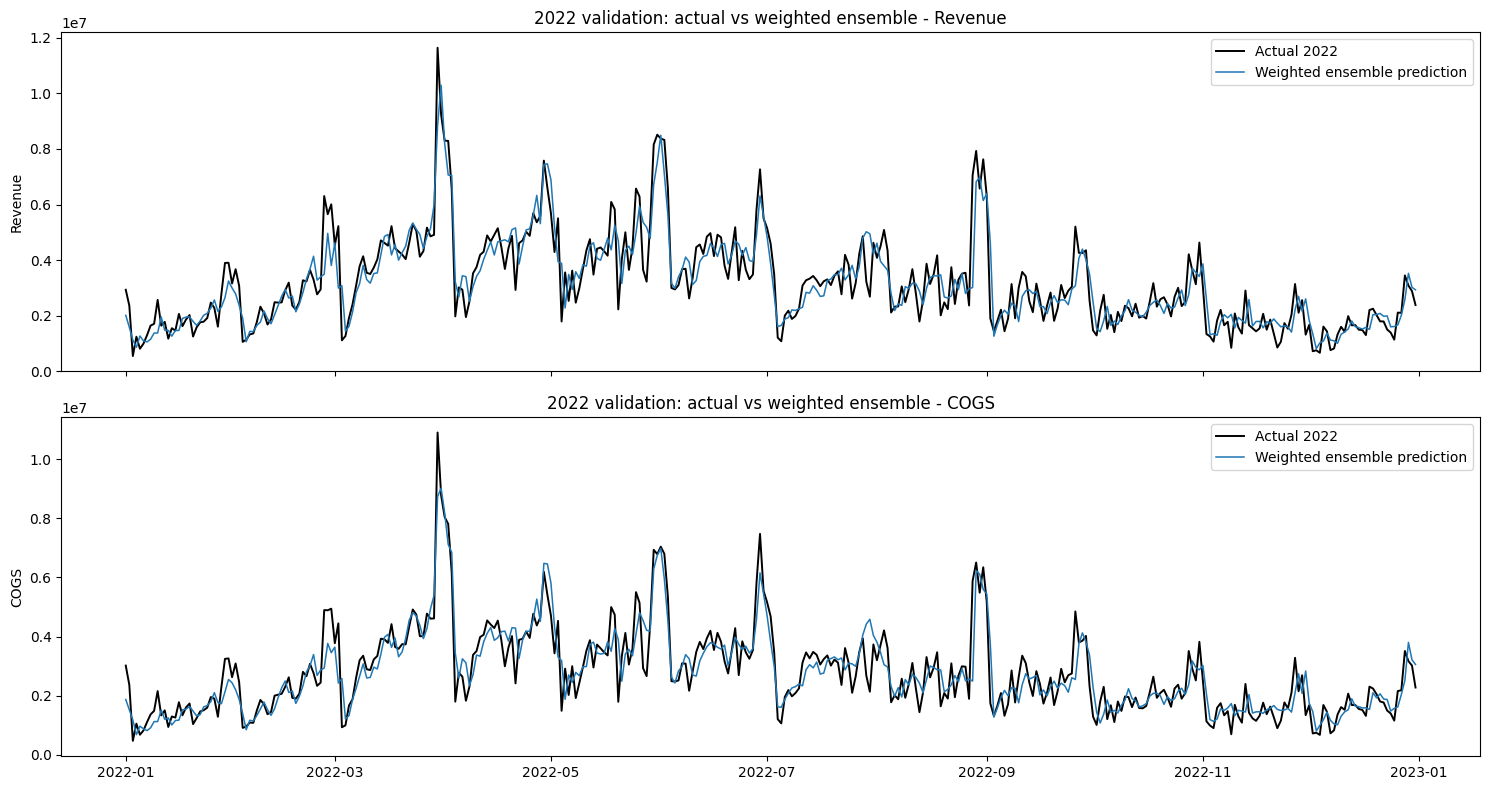

In [17]:
# 2022 validation plot for the weighted ensemble only.
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for target_idx, target in enumerate(TARGET_COLS):
    ax = axes[target_idx]
    ax.plot(model_table.loc[val_mask, "Date"], y_val[target], label="Actual 2022", color="black", linewidth=1.4)
    ax.plot(
        model_table.loc[val_mask, "Date"],
        ensemble_val_pred[:, target_idx],
        label="Weighted ensemble prediction",
        linewidth=1.1,
        color="tab:blue",
    )
    ax.set_title(f"2022 validation: actual vs weighted ensemble - {target}")
    ax.set_ylabel(target)
    ax.legend()

plt.tight_layout()
plt.show()


In [18]:
# Refit all ensemble component models on all available model-ready historical data before forecasting.
X_full = model_table[feature_cols]
y_full = model_table[TARGET_COLS]

final_component_models = {}

ridge_final = make_pipeline(
    StandardScaler(),
    MultiOutputRegressor(Ridge(alpha=10.0, random_state=RANDOM_SEED)),
)
ridge_final.fit(X_full, y_full)
final_component_models["ridge"] = ridge_final

rf_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_final.fit(X_full, y_full)
final_component_models["random_forest"] = rf_final

for trial in boosting_trials:
    params = {k: trial[k] for k in ["n_estimators", "learning_rate", "max_depth", "num_leaves", "subsample", "colsample_bytree"]}
    _, base_estimator = get_boosting_estimator(params)
    model = MultiOutputRegressor(base_estimator)
    model.fit(X_full, y_full)
    final_component_models[trial["model_name"]] = model

print("Final component models:", list(final_component_models.keys()))
print("Final training rows:", len(X_full))


Final component models: ['ridge', 'random_forest', 'lightgbm_trial_1', 'lightgbm_trial_2', 'lightgbm_trial_3']
Final training rows: 3468


## 5. Forecast Generation

Forecast `Revenue` and `COGS` recursively from `2023-01-01` through `2024-07-01`.

The recursive loop appends each prediction to the history, rebuilds lag/rolling features, and uses those generated values for later forecast dates. The final file is reindexed to the official `sample_submission.csv` row order.

In [19]:
def recursive_forecast(
    history: pd.DataFrame,
    model,
    feature_cols: list[str],
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    history_plus_predictions = history[["Date", *TARGET_COLS]].copy().sort_values("Date").reset_index(drop=True)
    forecast_dates = pd.date_range(start_date, end_date, freq="D")
    rows = []

    for forecast_date in forecast_dates:
        next_row = pd.DataFrame({"Date": [forecast_date], "Revenue": [np.nan], "COGS": [np.nan]})
        working = pd.concat([history_plus_predictions, next_row], ignore_index=True)
        working_features = make_features(working)
        X_next = working_features.loc[working_features["Date"] == forecast_date, feature_cols]

        if X_next.isna().any(axis=None):
            missing = X_next.columns[X_next.isna().any()].tolist()
            raise ValueError(f"Missing recursive features for {forecast_date.date()}: {missing[:10]}")

        pred = np.maximum(model.predict(X_next)[0], 0)
        predicted_row = {"Date": forecast_date, "Revenue": float(pred[0]), "COGS": float(pred[1])}
        rows.append(predicted_row)
        history_plus_predictions = pd.concat([history_plus_predictions, pd.DataFrame([predicted_row])], ignore_index=True)

    return pd.DataFrame(rows)


def recursive_seasonal_naive_forecast(
    history: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
) -> pd.DataFrame:
    history_plus_predictions = history[["Date", *TARGET_COLS]].copy().sort_values("Date").reset_index(drop=True)
    rows = []
    for forecast_date in pd.date_range(start_date, end_date, freq="D"):
        pred = history_plus_predictions[TARGET_COLS].iloc[-365].to_numpy(dtype=float)
        predicted_row = {"Date": forecast_date, "Revenue": float(max(pred[0], 0)), "COGS": float(max(pred[1], 0))}
        rows.append(predicted_row)
        history_plus_predictions = pd.concat([history_plus_predictions, pd.DataFrame([predicted_row])], ignore_index=True)
    return pd.DataFrame(rows)


def combine_component_forecasts(
    component_forecasts: dict[str, pd.DataFrame],
    weights_by_target: dict[str, np.ndarray],
    model_names: list[str],
) -> pd.DataFrame:
    out = component_forecasts[model_names[0]][["Date"]].copy()
    for target in TARGET_COLS:
        target_pred = np.zeros(len(out))
        for model_name, weight in zip(model_names, weights_by_target[target]):
            target_pred += weight * component_forecasts[model_name][target].to_numpy()
        out[target] = np.maximum(target_pred, 0)
    return out

component_forecasts = {
    "seasonal_naive": recursive_seasonal_naive_forecast(daily_sales, FORECAST_START, FORECAST_END)
}
for model_name, model in final_component_models.items():
    print("Forecasting component:", model_name)
    component_forecasts[model_name] = recursive_forecast(daily_sales, model, feature_cols, FORECAST_START, FORECAST_END)

forecast = combine_component_forecasts(component_forecasts, ensemble_weights, ensemble_model_names)
print(forecast.shape)
forecast.head()


Forecasting component: ridge
Forecasting component: random_forest
Forecasting component: lightgbm_trial_1
Forecasting component: lightgbm_trial_2
Forecasting component: lightgbm_trial_3
(548, 3)


,Date,Revenue,COGS
0,2023-01-01,2.553642e+06,2.274612e+06
1,2023-01-02,2.015372e+06,1.877419e+06
2,2023-01-03,1.374566e+06,1.156561e+06
3,2023-01-04,1.371871e+06,1.056624e+06
4,2023-01-05,1.231414e+06,1.014604e+06


In [20]:
submission = sample_submission[["Date"]].merge(forecast, on="Date", how="left")
assert submission[TARGET_COLS].notna().all().all()
assert submission["Date"].tolist() == sample_submission["Date"].tolist()

submission_to_save = submission.copy()
submission_to_save["Date"] = submission_to_save["Date"].dt.strftime("%Y-%m-%d")
submission_to_save[TARGET_COLS] = submission_to_save[TARGET_COLS].round(2)
submission_to_save.to_csv(SUBMISSION_PATH, index=False)

print("Saved submission:", SUBMISSION_PATH)
submission_to_save.head()

Saved submission: D:\Project\DATATHON-2026-r1\submissions\submission_03_2_ensemble_forecast.csv


,Date,Revenue,COGS
0,2023-01-01,2553641.55,2274612.04
1,2023-01-02,2015372.12,1877418.71
2,2023-01-03,1374566.33,1156560.93
3,2023-01-04,1371871.19,1056623.51
4,2023-01-05,1231413.77,1014604.29


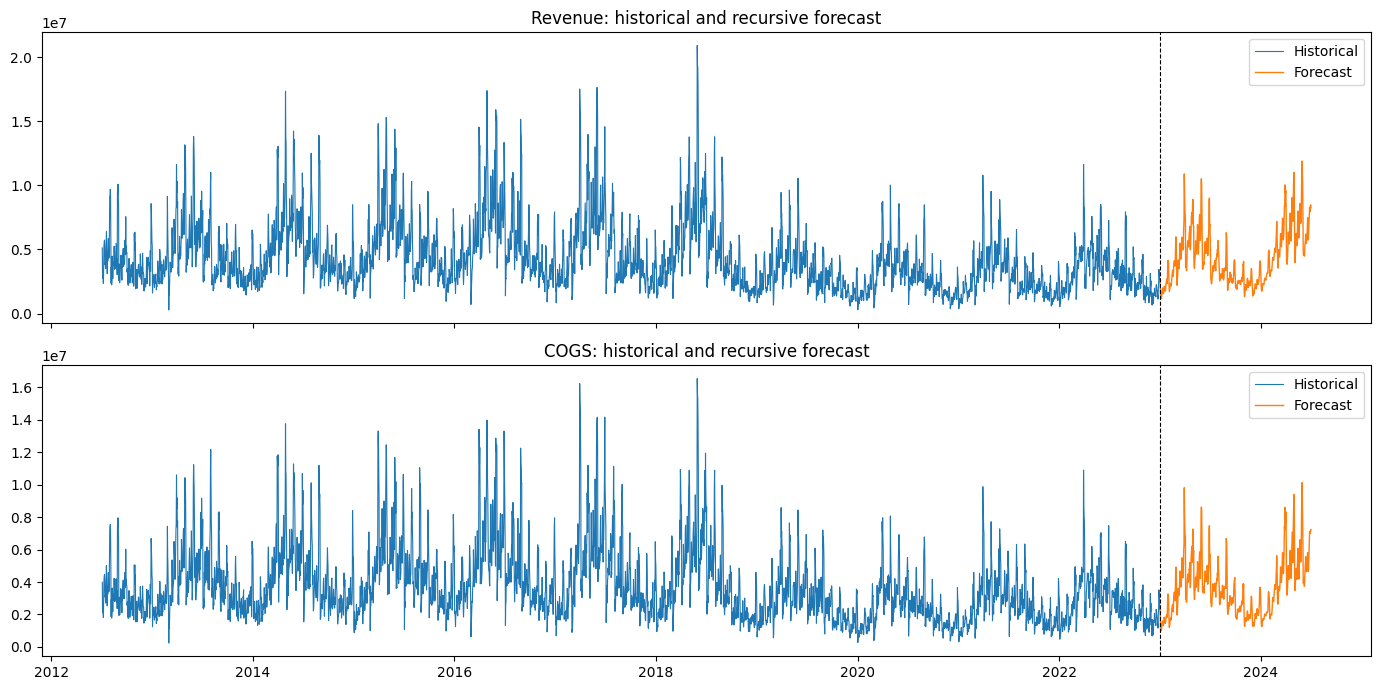

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, target in zip(axes, TARGET_COLS):
    ax.plot(daily_sales["Date"], daily_sales[target], label="Historical", linewidth=0.8)
    ax.plot(forecast["Date"], forecast[target], label="Forecast", linewidth=1.0)
    ax.axvline(FORECAST_START, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{target}: historical and recursive forecast")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Explainability

This section exports feature importance and, when available, SHAP values. The narrative translates the strongest drivers into business language.

In [22]:
def extract_feature_importance_from_components(models: dict[str, object], feature_cols: list[str]) -> pd.DataFrame:
    rows = []
    for model_name, model in models.items():
        estimators = getattr(model, "estimators_", None)
        if estimators is None and hasattr(model, "named_steps"):
            multi = model.named_steps.get("multioutputregressor")
            estimators = getattr(multi, "estimators_", None)
        if estimators is None:
            continue

        for target, estimator in zip(TARGET_COLS, estimators):
            if hasattr(estimator, "feature_importances_"):
                importances = estimator.feature_importances_
            elif hasattr(estimator, "coef_"):
                importances = np.abs(estimator.coef_)
            else:
                continue
            for feature, importance in zip(feature_cols, importances):
                rows.append({
                    "model": model_name,
                    "target": target,
                    "feature": feature,
                    "importance": float(importance),
                })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["importance_share"] = out.groupby(["model", "target"])["importance"].transform(lambda s: s / s.sum() if s.sum() else 0)
    return out.sort_values(["model", "target", "importance"], ascending=[True, True, False]).reset_index(drop=True)

feature_importance = extract_feature_importance_from_components(final_component_models, feature_cols)
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
feature_importance.groupby(["model", "target"]).head(8)


,model,target,feature,importance,importance_share
0,lightgbm_trial_1,COGS,dayofmonth,520.000000,0.098058
1,lightgbm_trial_1,COGS,COGS_lag_365,356.000000,0.067132
2,lightgbm_trial_1,COGS,COGS_lag_1,310.000000,0.058457
3,lightgbm_trial_1,COGS,COGS_lag_7,236.000000,0.044503
4,lightgbm_trial_1,COGS,COGS_roll_min_7,182.000000,0.034320
...,...,...,...,...,...
615,ridge,Revenue,COGS_lag_1,558682.099239,0.049739
616,ridge,Revenue,month_sin,534566.564430,0.047592
617,ridge,Revenue,weekofyear_sin,492093.363203,0.043810
618,ridge,Revenue,gross_margin_lag_1,424917.255382,0.037830


In [23]:
# SHAP is skipped in the ensemble notebook because the final prediction is a weighted blend of several recursive models.
# Use the exported per-component feature importance table for model diagnostics.
shap_summary = pd.DataFrame()


In [24]:
def business_driver_summary(feature_importance: pd.DataFrame, top_n: int = 8) -> None:
    if feature_importance.empty:
        print("No feature importance available.")
        return
    for model_name in feature_importance["model"].unique():
        print()
        print(f"{model_name} major drivers")
        for target in TARGET_COLS:
            top_features = (
                feature_importance
                .loc[(feature_importance["model"] == model_name) & (feature_importance["target"] == target)]
                .head(top_n)["feature"]
                .tolist()
            )
            print(f"  {target}:", ", ".join(top_features))

business_driver_summary(feature_importance)



lightgbm_trial_1 major drivers
  Revenue: dayofmonth, Revenue_lag_1, COGS_lag_365, Revenue_lag_7, COGS_lag_1, gross_margin_lag_1, dayofyear_sin, Revenue_lag_365
  COGS: dayofmonth, COGS_lag_365, COGS_lag_1, COGS_lag_7, COGS_roll_min_7, COGS_lag_14, Revenue_lag_365, dayofyear_sin

lightgbm_trial_2 major drivers
  Revenue: dayofmonth, Revenue_lag_1, COGS_lag_365, Revenue_lag_7, gross_margin_lag_1, COGS_lag_1, Revenue_lag_365, cogs_to_revenue_lag_1
  COGS: dayofmonth, COGS_lag_365, COGS_lag_1, COGS_lag_7, COGS_lag_30, Revenue_lag_365, Revenue_lag_1, COGS_lag_14

lightgbm_trial_3 major drivers
  Revenue: dayofmonth, COGS_lag_365, Revenue_lag_1, COGS_lag_1, gross_margin_lag_1, Revenue_lag_7, dayofyear_sin, cogs_to_revenue_lag_1
  COGS: dayofmonth, COGS_lag_365, COGS_lag_1, Revenue_lag_365, COGS_lag_7, COGS_lag_30, Revenue_lag_1, COGS_roll_min_7

random_forest major drivers
  Revenue: Revenue_lag_1, Revenue_lag_365, COGS_lag_365, COGS_lag_1, Revenue_lag_14, Revenue_lag_7, COGS_lag_7, COGS_r

## 7. Reproducibility

The workflow uses a fixed random seed, stores validation results, and saves model configuration needed to reproduce the final run.

In [25]:
validation_table.to_csv(VALIDATION_RESULTS_PATH, index=False)
ensemble_weights_table.to_csv(ENSEMBLE_WEIGHTS_PATH, index=False)

model_config = {
    "random_seed": RANDOM_SEED,
    "target_cols": TARGET_COLS,
    "lags": LAGS,
    "rolling_windows": ROLLING_WINDOWS,
    "forecast_start": FORECAST_START.strftime("%Y-%m-%d"),
    "forecast_end": FORECAST_END.strftime("%Y-%m-%d"),
    "validation_year": VALIDATION_YEAR,
    "feature_count": len(feature_cols),
    "component_models": ensemble_model_names,
    "ensemble_weights": {
        target: {
            model_name: float(weight)
            for model_name, weight in zip(ensemble_model_names, ensemble_weights[target])
        }
        for target in TARGET_COLS
    },
    "submission_path": str(SUBMISSION_PATH.relative_to(PROJECT_ROOT)),
    "validation_results_path": str(VALIDATION_RESULTS_PATH.relative_to(PROJECT_ROOT)),
    "ensemble_weights_path": str(ENSEMBLE_WEIGHTS_PATH.relative_to(PROJECT_ROOT)),
    "feature_importance_path": str(FEATURE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)),
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("Saved validation results:", VALIDATION_RESULTS_PATH)
print("Saved ensemble weights:", ENSEMBLE_WEIGHTS_PATH)
print("Saved model config:", MODEL_CONFIG_PATH)
print("Saved feature importance:", FEATURE_IMPORTANCE_PATH)
model_config


Saved validation results: D:\Project\DATATHON-2026-r1\reports\tables\03_2_ensemble_validation_results.csv
Saved ensemble weights: D:\Project\DATATHON-2026-r1\reports\tables\03_2_ensemble_weights.csv
Saved model config: D:\Project\DATATHON-2026-r1\models\03_2_ensemble_model_config.json
Saved feature importance: D:\Project\DATATHON-2026-r1\reports\tables\03_2_ensemble_feature_importance.csv


{'random_seed': 42,
 'target_cols': ['Revenue', 'COGS'],
 'lags': [1, 7, 14, 30, 365],
 'rolling_windows': [7, 30, 90, 365],
 'forecast_start': '2023-01-01',
 'forecast_end': '2024-07-01',
 'validation_year': 2022,
 'feature_count': 68,
 'component_models': ['ridge',
  'random_forest',
  'lightgbm_trial_1',
  'lightgbm_trial_2',
  'lightgbm_trial_3'],
 'ensemble_weights': {'Revenue': {'ridge': 0.25373160930309396,
   'random_forest': 1.4683249940297994e-05,
   'lightgbm_trial_1': 8.432382175405273e-06,
   'lightgbm_trial_2': 0.6931612554233437,
   'lightgbm_trial_3': 0.0530840196414466},
  'COGS': {'ridge': 0.1507536858657508,
   'random_forest': 4.2353366261217484e-11,
   'lightgbm_trial_1': 1.7162839731105228e-10,
   'lightgbm_trial_2': 0.5802465753799612,
   'lightgbm_trial_3': 0.2689997385403064}},
 'submission_path': 'submissions\\submission_03_2_ensemble_forecast.csv',
 'validation_results_path': 'reports\\tables\\03_2_ensemble_validation_results.csv',
 'ensemble_weights_path': '